### Single-step & Multi-step Forecasts of Next Week's Energy Consumption

In [2]:
'''
!pip install pandas
!pip install numpy
!pip install seaborn
!pip install matplotlib
!pip install scikit-learn
!pip install statsmodels
!pip install keras
!pip install mflow
!pip install tensorflow
!pip install mlflow
!pip install keras-tuner
'''

'\n!pip install pandas\n!pip install numpy\n!pip install seaborn\n!pip install matplotlib\n!pip install scikit-learn\n!pip install statsmodels\n!pip install keras\n!pip install mflow\n!pip install tensorflow\n!pip install mlflow\n!pip install keras-tuner\n'

In [3]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import random
import tensorflow as tf
from keras.models import Sequential
from keras.layers import LSTM, GRU, Dense, Dropout, BatchNormalization, Activation, Reshape
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import r2_score
from keras.layers import RepeatVector
from keras.layers import TimeDistributed
#from tensorflow.keras.layers import LSTM, Dense, Dropout, RepeatVector, TimeDistributed, Reshape
from tensorflow.keras.layers import RepeatVector, TimeDistributed
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import keras_tuner
from tensorflow.keras.models import load_model




/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:82: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


#### DATA LOADING

In [ ]:

dataset_path = "../data/Tetuan City power consumption.csv"
data = pd.read_csv(dataset_path, parse_dates=["DateTime"], index_col=["DateTime"])
data.head()

,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption
DateTime,,,,,,,,
2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


In [6]:
window_size = 6
target_columns=['Zone 1 Power Consumption', 'Zone 2  Power Consumption','Zone 3  Power Consumption']


In [7]:
def create_sliding_window(groups, input_days=window_size, output_days=1, target_columns = target_columns):
    X, y = [], []
    # Get indices of target columns
    target_indices = [data.columns.get_loc(col) for col in target_columns]
    for group in groups:
        for i in range(len(group) - input_days - output_days + 1):
            X.append(group.iloc[i:i + input_days].values)
            y.append(group.iloc[i + input_days:i + input_days + output_days, target_indices].values)
    return np.array(X), np.array(y)

In [8]:
def evaluate_model(model, X_test, y_test):

    y_pred = model.predict(X_test)
    # Inverse transform predictions
    y_pred_flat = y_pred.reshape(-1, 3)
    y_pred_inv = scaler.inverse_transform(np.concatenate([np.zeros((y_pred_flat.shape[0], X_test.shape[2]-3)), y_pred_flat], axis=1))[:, -3:]


    mae = mean_absolute_error(y_test.flatten(), y_pred.flatten())
    rmse = np.sqrt(mean_squared_error(y_test.flatten(), y_pred.flatten()))
    r2 = r2_score(y_test.flatten(), y_pred.flatten())


    print(f'Mean Absolute Error: {mae}')
    print(f'Root Mean Squared Error: {rmse}')
    print(f'R² Score: {r2}')

    return y_pred, y_test


### DATA PROCESSING

In [10]:
# Step 1: Identify and Interpolate Outliers
column_group = ['Zone 1 Power Consumption', 'Zone 2  Power Consumption','Zone 3  Power Consumption']

data[column_group] = data[column_group].ffill().bfill()

data_wk = data.copy()
data_wk_sorted = data_wk.sort_index()

# Mask and interpolate outliers
for col in ['general diffuse flows', 'Zone 3  Power Consumption', 'diffuse flows']:
    rolling_mean = data_wk_sorted[col].rolling(window=window_size).mean()
    rolling_std = data_wk_sorted[col].rolling(window=window_size).std()
    outliers = (data_wk_sorted[col] - rolling_mean).abs() > 3 * rolling_std
    data_wk_sorted.loc[outliers, col] = None

data_wk_sorted[['general diffuse flows', 'Zone 3  Power Consumption', 'diffuse flows']] = \
    data_wk_sorted[['general diffuse flows', 'Zone 3  Power Consumption', 'diffuse flows']].interpolate(method='linear')

# Step 2: Resample Daily & Encode Seasonality. Add sine/cosine encoding for week-of-year
week_of_year = data_wk_sorted.index.isocalendar().week
data_wk_sorted['sin_week'] = np.sin(2 * np.pi * week_of_year / 52)
data_wk_sorted['cos_week'] = np.cos(2 * np.pi * week_of_year / 52)

weekly_groups = [group for _, group in data.resample('W-MON')]

In [11]:

# Split into training and test sets
train_size = int(len(weekly_groups) * 0.8)
train_groups = weekly_groups[:train_size]
test_groups = weekly_groups[train_size:]


In [12]:

# Normalise the train_groups and test groups
scaler = MinMaxScaler()
train_groups_scaled = [pd.DataFrame(scaler.fit_transform(group), index=group.index, columns=group.columns) for group in train_groups]

test_groups_scaled = [pd.DataFrame(scaler.transform(group), index=group.index, columns=group.columns) for group in test_groups]

X_train, y_train = create_sliding_window(train_groups_scaled, input_days=window_size, output_days=1, target_columns= target_columns)

X_test, y_test = create_sliding_window(test_groups_scaled, input_days=window_size, output_days=1, target_columns= target_columns)

In [13]:
n_timesteps       = X_train.shape[1]
n_features        = X_train.shape[2]
n_output_features = y_train.shape[2]

### Hyper Parameter Tuning

In [14]:
def build(hp):
  model = Sequential()
  model.add(LSTM(hp.Int('units', min_value=32, max_value=512, step=32), activation='relu', input_shape=(n_timesteps, n_features), return_sequences=True)) # Added return_sequences=True
  model.add(Dropout(hp.Float('dropout 1', min_value=0.0, max_value=0.5, step=0.1)))
  model.add(LSTM(hp.Int('units_2', min_value=32, max_value=128, step=32), activation='relu', return_sequences=False))
  model.add(Dropout(hp.Float('dropout_2', min_value=0.0, max_value=0.5, step=0.1)))
  model.add(Dense(n_output_features, activation='linear'))
  model.add(Reshape((1, n_output_features)))
  model.compile(optimizer=tf.keras.optimizers.Adam(hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])),loss='mse',metrics=['mse'])
  return model

In [15]:
# Instantiate the tuner
tuner = keras_tuner.RandomSearch(
    hypermodel=build,
    objective=keras_tuner.Objective("val_loss", direction="min"),
    max_trials=10,
    executions_per_trial=2,
    overwrite=True,
    directory="my_dir_weekly",
    project_name="my_project",
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [16]:
# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-5)

In [17]:
#Run the hyperparameter search
tuner.search(X_train, y_train, epochs=100, validation_split=0.2, callbacks=[early_stopping, reduce_lr])
#Retrieve the best Model
best_model_wk = tuner.get_best_models(num_models=1)[0]
best_model_wk.summary()
best_params_wk = tuner.get_best_hyperparameters()[0].values
print(f'Best param : {best_params_wk}')
#Train the optimised model
history_wk = best_model_wk.fit(X_train, y_train, epochs=100, validation_split=0.2, callbacks=[early_stopping, reduce_lr])



Trial 10 Complete [00h 02m 48s]
val_loss: 0.005053772707469761

Best val_loss So Far: 0.00020089095778530464
Total elapsed time: 02h 40m 00s


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 6, 480)         │       938,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 480)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 96)             │       221,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           291 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 1, 3)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,160,739 (4.43 MB)

 Trainable params: 1,160,739 (4.43 MB)

 Non-trainable params: 0 (0.00 B)

Best param : {'units': 480, 'dropout 1': 0.2, 'units_2': 96, 'dropout_2': 0.1, 'learning_rate': 0.001}
Epoch 1/100
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - loss: 8.1135e-04 - mse: 8.1135e-04 - val_loss: 3.2723e-04 - val_mse: 3.2723e-04 - learning_rate: 0.0010
Epoch 2/100
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 8.0494e-04 - mse: 8.0494e-04 - val_loss: 3.2553e-04 - val_mse: 3.2553e-04 - learning_rate: 0.0010
Epoch 3/100
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 7.7548e-04 - mse: 7.7548e-04 - val_loss: 2.2836e-04 - val_mse: 2.2836e-04 - learning_rate: 0.0010
Epoch 4/100
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 7.5385e-04 - mse: 7.5385e-04 - val_loss: 4.2889e-04 - val_mse: 4.2889e-04 - learning_rate: 0.0010
Epoch 5/100
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 6.6779e-04 - mse: 6.6779e-04 - val_loss: 2.1015e-04 - val_mse: 2.1015e-04 - learning_rate: 2.0000e-04
Epoch 6/100
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 6.4547e-04 - 

In [18]:
best_params_wk

{'units': 480,
 'dropout 1': 0.2,
 'units_2': 96,
 'dropout_2': 0.1,
 'learning_rate': 0.001}

In [19]:
#Save the best model on Google drive
# Save to a local path first
local_save_path = '/content/best_model_wk.h5'
best_model_wk.save(local_save_path)

# Then copy to Google Drive
# Make sure you have mounted Google Drive using the previous cell
!cp {local_save_path} /content/drive/MyDrive/best_model_wk.h5

#### End: Hyper-Parameter Tuning

336/336 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Mean Absolute Error: 0.045268721001738975
Root Mean Squared Error: 0.07067927882476777
R² Score: 0.950349433838819
Zone 1 - RMSE: 1420.08, MAE: 1021.50, R²: 0.95


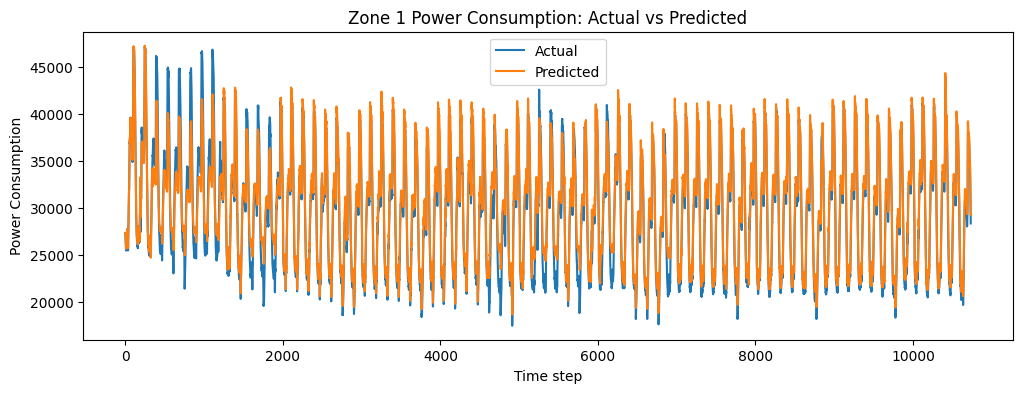

Zone 2 - RMSE: 1379.24, MAE: 854.27, R²: 0.94


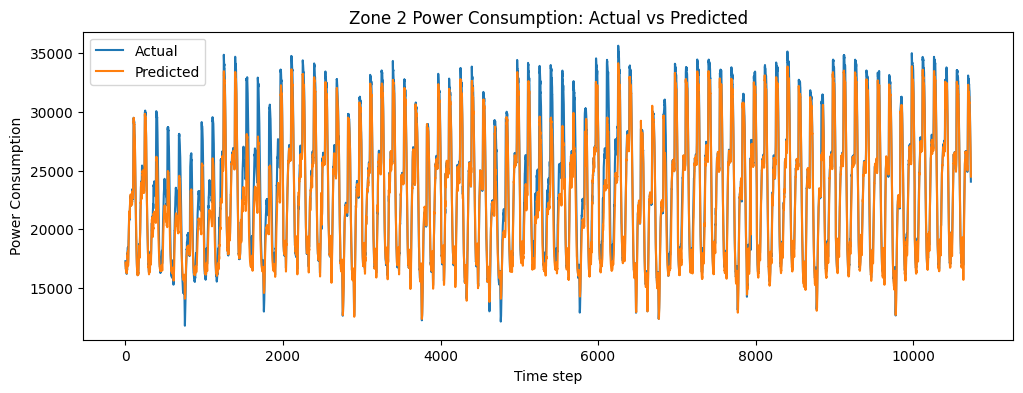

Zone 3 - RMSE: 943.99, MAE: 584.94, R²: 0.92


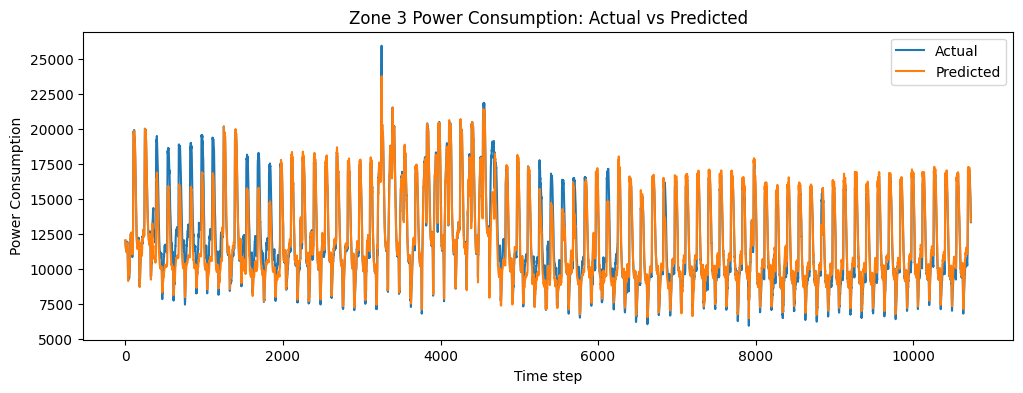

In [93]:
# Evaluate and plot predictions for all zones with correct shape handling
y_pred, y_test = evaluate_model(best_model_wk, X_test, y_test)


n_features = X_test.shape[2]
n_targets = 3

# Flatten predictions and targets to 2D (samples*timesteps, n_targets)
y_pred_flat = y_pred.reshape(-1, n_targets)
y_test_flat = y_test.reshape(-1, n_targets)

# Pad with zeros for non-target columns to match scaler input shape
y_pred_padded = np.concatenate([np.zeros((y_pred_flat.shape[0], n_features - n_targets)), y_pred_flat], axis=1)
y_test_padded = np.concatenate([np.zeros((y_test_flat.shape[0], n_features - n_targets)), y_test_flat], axis=1)

# Inverse transform
try:
    y_pred_inv = scaler.inverse_transform(y_pred_padded)[:, -n_targets:]
    y_test_inv = scaler.inverse_transform(y_test_padded)[:, -n_targets:]
except Exception as e:
    print('Inverse transform error:', e)
    y_pred_inv = y_pred_flat
    y_test_inv = y_test_flat

# Calculate metrics for each target (zone)

for i, zone in enumerate(['Zone 1', 'Zone 2', 'Zone 3']):
    rmse = np.sqrt(mean_squared_error(y_test_inv[:, i], y_pred_inv[:, i]))
    mae = mean_absolute_error(y_test_inv[:, i], y_pred_inv[:, i])
    r2 = r2_score(y_test_inv[:, i], y_pred_inv[:, i])
    print(f'{zone} - RMSE: {rmse:.2f}, MAE: {mae:.2f}, R²: {r2:.2f}')
    # Plot actual vs predicted
    plt.figure(figsize=(12, 4))
    plt.plot(y_test_inv[:, i], label='Actual')
    plt.plot(y_pred_inv[:, i], label='Predicted')
    plt.title(f'{zone} Power Consumption: Actual vs Predicted')
    plt.xlabel('Time step')
    plt.ylabel('Power Consumption')
    plt.legend()
    plt.show()




In [77]:
def walk_forward_forecast(model, test_groups_scaled, scaler, input_days=6, output_days=1, target_columns=['Zone 1 Power Consumption', 'Zone 2  Power Consumption','Zone 3  Power Consumption']):

    """
    Walk-forward validation: for each test week, use the previous six weeks as input, predict the next week,
    update history, store predictions, and print total and daily scores for each zone.
    """
    import numpy as np
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    import matplotlib.pyplot as plt

    history = [group.copy() for group in test_groups_scaled[:2]]  # start with first 2 weeks
    predictions = []
    actuals = []
    n_features = history[0].shape[1]
    n_targets = len(target_columns)
    target_indices = [history[0].columns.get_loc(col) for col in target_columns]

    for i in range(2, len(test_groups_scaled)):
        # Prepare input from last two weeks
        input_data = pd.concat(history[-2:])
        X = []
        for j in range(len(input_data) - input_days + 1):
            X.append(input_data.iloc[j:j + input_days].values)
        X = np.array(X)
        if X.shape[0] == 0:
            continue
        # Predict next week
        y_pred = model.predict(X[-1:])  # use the last window
        # Inverse transform prediction
        y_pred_flat = y_pred.reshape(-1, n_targets)
        y_pred_padded = np.concatenate([np.zeros((y_pred_flat.shape[0], n_features - n_targets)), y_pred_flat], axis=1)
        y_pred_inv = scaler.inverse_transform(y_pred_padded)[:, -n_targets:]
        predictions.append(y_pred_inv)
        # Get actual next week
        actual_week = test_groups_scaled[i].iloc[:output_days, target_indices].values
        actual_padded = np.concatenate([np.zeros((actual_week.shape[0], n_features - n_targets)), actual_week], axis=1)
        actual_inv = scaler.inverse_transform(actual_padded)[:, -n_targets:]
        actuals.append(actual_inv)
        # Update history with actual week
        history.append(test_groups_scaled[i])

    # Stack predictions and actuals
    predictions = np.vstack(predictions)
    actuals = np.vstack(actuals)

    # Ensure actuals and predictions have the same length by taking the minimum length
    min_len = min(len(actuals), len(predictions))
    actuals = actuals[:min_len]
    predictions = predictions[:min_len]


    # Print total and daily scores for each zone
    for idx, zone in enumerate(['Zone 1', 'Zone 2', 'Zone 3']):
        rmse = np.sqrt(mean_squared_error(actuals[:, idx], predictions[:, idx]))
        mae = mean_absolute_error(actuals[:, idx], predictions[:, idx])


    return predictions, actuals

In [80]:

pred_next_week = best_model_wk.predict(X_test[-1:])
pred_next_week_flat = pred_next_week.reshape(-1, 3)
#Inverse transform to actual values
pred_next_week_inv = scaler.inverse_transform(np.concatenate([np.zeros((pred_next_week_flat.shape[0], X_test.shape[2]-3)), pred_next_week_flat], axis=1))[:, -3:]
pred_next_week_inv*1008


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


array([[29493411.20554172, 24678604.61815789, 13506895.03005582]])

In [ ]:
#Load the best model without compilation information

best_model_wk_loaded = load_model('/content/drive/MyDrive/best_model_wk.h5', compile=False)


learning_rate= best_params_wk['learning_rate']


best_model_wk_loaded.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse', metrics=['mse'])

best_model_wk_loaded.summary()

In [75]:
predictions, actuals = walk_forward_forecast(best_model_wk, test_groups_scaled, scaler, input_days=6, output_days=7, target_columns=['Zone 1 Power Consumption', 'Zone 2  Power Consumption','Zone 3  Power Consumption'])

# Calculate total predicted consumption for the next week for each zone

total_predicted_next_week = predictions.sum(axis=0) * 1008

# Print total predicted consumption for each zone
for i, zone in enumerate(['Zone 1', 'Zone 2', 'Zone 3']):
    print(f'{zone} total predicted consumption for the next week: {total_predicted_next_week[i]:.2f}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Zone 1 total predicted consumption for the next week: 250253915.64
Zone 2 total predicted consumption for the next week: 203695209.28
Zone 3 total predicted consumption for the next week: 111096277.39


In [83]:
def multi_step_forecast(model, last_sequence, x_scaler, n_steps, n_features, n_output_features):
    predictions = []
    current_input = last_sequence.copy()

    pad_cols = n_features - n_output_features

    for _ in range(n_steps):
        # Predict next step (output is scaled)
        y_pred_scaled = best_model_wk.predict(current_input) # Removed .sum(axis=0)

        # Inverse transform for storing and displaying
        zeros_for_pred_inv = np.zeros((1, pad_cols))
        pred_full_inv = np.concatenate([zeros_for_pred_inv, y_pred_scaled.reshape(1, n_output_features)], axis=1)
        inv_pred = x_scaler.inverse_transform(pred_full_inv)[:, -n_output_features:]
        predictions.append(inv_pred.flatten())

        # Prepare the scaled prediction to be appended to the input sequence
        zeros_for_pred_scaled = np.zeros((1, 1, pad_cols))
        padded_pred_scaled = np.concatenate([zeros_for_pred_scaled, y_pred_scaled], axis=2)

        # Update input sequence by removing oldest timestep and appending new scaled prediction
        current_input = np.concatenate([current_input[:, 1:, :], padded_pred_scaled], axis=1)

    return np.array(predictions)

In [92]:
predictions = np.round((multi_step_forecast(best_model_wk, X_test[-1:], scaler, 7, n_features, n_output_features)*1008),2)

pred_df = pd.DataFrame(predictions, columns=['Zone 1', 'Zone 2', 'Zone 3'])
print(pred_df)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
        Zone 1       Zone 2       Zone 3
0  29493411.21  24678604.62  13506895.03
1  29355593.00  24330252.75  13241253.53
2  29430953.82  24161405.53  13105983.39
3  29518321.30  24012088.36  12984391.11
4  29641479.46  23905097.57  12880083.86
5  29799078.22  23844972.20  12804909.41
6  30061549.48  24035155.82  12815434.09
